In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from matplotlib import pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
import pickle

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from PIL import Image

In [2]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


## Convolutional Neural Network Architecture ကို တည်ဆောက်ခြင်း

Medium Article ပြောထားတဲ့အတိုင်း Convolution, Activation, Max Pooling နဲ့ \
နောက်ဆုံးမှာ Linear Layer (Raw Logits) တွေ ပါဝင်မယ့် Simple CNN တစ်ခုကို တည်ဆောက်ပါမယ်။

In [3]:
class BurmeseDigitCNN(nn.Module):
    def __init__(self):
        super(BurmeseDigitCNN, self).__init__()

        # 1. Convolutional Layer: ပုံရိပ်ထဲမှ (Features) များကို ထုတ်ယူရန်
        # Input channel = 1 (Grayscale), Output channels = 32, Kernel size = 3x3
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)

        # 2. Max Pooling: ပုံရိပ်၏ အရွယ်အစားကို လျှော့ချရန်
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3. Convolutional Layer 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # 4. Fully Connected Layers: ရရှိလာသော Features များကို အခြေခံ၍ ဂဏန်းခွဲခြားရန်
        # 28x28 ပုံသည် pool နှစ်ခါလုပ်ပြီးနောက် 7x7 ဖြစ်သွားမည်
        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        # နောက်ဆုံး Output Layer: ဂဏန်း ၁၀ လုံး (၀ မှ ၉) ရှိသောကြောင့် Output size = 10
        # ဤနေရာမှ ထွက်လာသော ရလဒ်သည် Raw Logits ဖြစ်သည်
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Forward Pass အဆင့်ဆင့် တွက်ချက်ခြင်း
        x = self.pool(F.relu(self.conv1(x)))  # Conv1 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))  # Conv2 -> ReLU -> Pool

        # Matrix ကို Linear layer ထဲထည့်ရန်အတွက် Vector ပုံစံသို့ ဖြန့်ချခြင်း (Flatten)
        x = x.view(-1, 64 * 7 * 7)
        # Hidden Layer -> ReLU
        x = F.relu(self.fc1(x))
        # Final Layer (Raw Logits)
        x = self.fc2(x)

        return x

model = BurmeseDigitCNN().to(device)

Classification အတွက် Cross Entropy Loss ကို အသုံးပြုပြီး၊ \
Weight တွေကို Update လုပ်ဖို့ Gradient Descent ကတော့ Adam Optimizer ကို သုံးပါမယ်။

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
def train_model(epochs, train_loader):
    # Model ကို Training mode သို့ ပြောင်းခြင်း
    model.train() 

    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # ၁။ Optimizer ကို Zero ပေးခြင်း (အရင် gradient များ မကျန်စေရန်)
            optimizer.zero_grad()

            # ၂။ Forward Pass: Model မှ ခန့်မှန်းချက် ထုတ်ယူခြင်း
            outputs = model(images)

            # ၃။ Loss တွက်ချက်ခြင်း: ခန့်မှန်းချက်နှင့် အဖြေမှန် ဘယ်လောက်ကွာသလဲ ကြည့်ခြင်း
            loss = criterion(outputs, labels)

            # ၄။ Backpropagation တွက်ပြီး Gradient ရှာခြင်း
            loss.backward()

            # ၅။ Loss Landscape ၏ အဆင်းဘက် (အမှားအနည်းဆုံးနေရာ) သို့ ဦးတည်၍ 
            # Weight တန်ဖိုးများကို တစ်လှမ်းချင်း (Step) ပြုပြင်ပြောင်းလဲပေးခြင်း ဖြစ်ပါသည်။
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

In [6]:
def test_model(test_loader):
    # Model ကို ခန့်မှန်းရုံသက်သက် (Inference mode) သို့ ပြောင်းခြင်း
    model.eval()

    all_preds = []
    all_probs = []

    # Gradient တွက်ရန် မလိုသောကြောင့် ပိတ်ထားခြင်း
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())

    return all_preds, all_probs

## Burmese Handwritten Digits ဒေတာများဖတ်ယူခြင်း

In [7]:
dataset = []

with open("../BHDD/data.pkl","rb") as file:
    dataset = pickle.load(file)

trainDataset = dataset["trainDataset"]
testDataset = dataset["testDataset"]

print("Train Size: {} Test Size: {}".format(len(trainDataset), len(testDataset)))

numberOfClass = 10

trainX = [list(td["image"].flatten() / 255) for td in trainDataset]
trainY = np.eye(numberOfClass)[np.array([td["label"] for td in trainDataset]).reshape(-1)].tolist() #One-hot encode training labels
testX = [list(td["image"].flatten() / 255) for td in testDataset]
testY = np.eye(numberOfClass)[np.array([td["label"] for td in testDataset]).reshape(-1)].tolist() #One-hot encode test labels

print("TrainImageShape:" + str(np.shape(trainX)),
     "TrainLabelShape:" + str(np.shape(trainY)),
     "TestImageShape:" + str(np.shape(testX)),
     "TestLabelShape:" + str(np.shape(testY)))

/var/folders/d7/5xjp058538n1_2xf1mtj_bwr0000gn/T/ipykernel_8843/2141504325.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dataset = pickle.load(file)


Train Size: 60000 Test Size: 27561
TrainImageShape:(60000, 784) TrainLabelShape:(60000, 10) TestImageShape:(27561, 784) TestLabelShape:(27561, 10)


In [8]:
# ၁။ List/NumPy မှ PyTorch Tensor သို့ ပြောင်းလဲခြင်း
# Images များကို (Batch, Channel, Height, Width) ပုံစံဖြစ်အောင် reshaped လုပ်ရပါမည်
X_train_tensor = torch.tensor(trainX).float().view(-1, 1, 28, 28)

# CrossEntropyLoss အတွက် Labels များကို One-hot မဟုတ်ဘဲ Long Tensor (Class Indices) အဖြစ် ပြောင်းရပါမည်
Y_train_tensor = torch.tensor([td["label"] for td in trainDataset]).long()

train_data = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

Training Phase (သင်ယူနေသည့်အဆင့်)

In [9]:
train_model(10, train_loader)

Epoch 1/10, Loss: 0.0791
Epoch 2/10, Loss: 0.0147
Epoch 3/10, Loss: 0.0095
Epoch 4/10, Loss: 0.0062
Epoch 5/10, Loss: 0.0051
Epoch 6/10, Loss: 0.0038
Epoch 7/10, Loss: 0.0032
Epoch 8/10, Loss: 0.0024
Epoch 9/10, Loss: 0.0022
Epoch 10/10, Loss: 0.0021


## Model ၏ စွမ်းဆောင်ရည်ကို Test Dataset ဖြင့် စစ်ဆေးခြင်း

ဤအဆင့်တွင် Model သည် မမြင်ဖူးသေးသော ဒေတာအသစ်များ (Test Dataset) အပေါ်တွင် မည်မျှ တိကျမှန်ကန်စွာ \
ခန့်မှန်းနိုင်သလဲဆိုသည်ကို တိုင်းတာရန်အတွက် `test_model` function ကို အသုံးပြုပါမည်။

In [10]:
# Inference Phase (အသုံးချသည့်အဆင့်)
X_test_tensor = torch.tensor(testX).float().view(-1, 1, 28, 28)
Y_test_tensor = torch.tensor([td["label"] for td in testDataset]).long()

test_data = TensorDataset(X_test_tensor, Y_test_tensor)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [11]:
preds, probs = test_model(test_loader)

In [12]:
y_true = []
for _, labels in test_loader:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(preds)

# Model ၏ စုစုပေါင်း ခန့်မှန်းချက် တိကျမှု ရာခိုင်နှုန်း (Accuracy) ကို တွက်ချက်ခြင်း
acc = accuracy_score(y_true, y_pred)

# မည်သည့်ဂဏန်းကို မည်သည့်ဂဏန်းနှင့် မှားယွင်းနေသလဲဆိုသည်ကို ဇယားဖြင့် ကြည့်ရှုခြင်း (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)

# Class တစ်ခုချင်းစီအလိုက် Precision, Recall နှင့် F1-score တို့ကို အသေးစိတ် ထုတ်ပြန်ခြင်း
report = classification_report(y_true, y_pred)

print(f"Accuracy: {acc * 100:.2f}%\n")
print("Confusion Matrix:\n", cm, "\n")
print("Classification Report:\n", report)

Accuracy: 99.71%

Confusion Matrix:
 [[6825   23    0    0    0    0    1    0    5    2]
 [   1 6156    0    0    0    2    0    1    3    0]
 [   0    3 4331    0    0    5    0    0    0    0]
 [   0    7    0 3467    6    0    0    0    0    0]
 [   1    0    0    0 2161    0    0    0    0    0]
 [   0    5    0    0    2 2225    0    1    4    0]
 [   1    0    0    0    0    0  498    0    0    1]
 [   0    0    0    0    0    0    0  608    1    1]
 [   2    0    0    0    0    0    0    0  822    1]
 [   0    0    0    0    0    0    0    0    0  389]] 

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6856
           1       0.99      1.00      1.00      6163
           2       1.00      1.00      1.00      4339
           3       1.00      1.00      1.00      3480
           4       1.00      1.00      1.00      2162
           5       1.00      0.99      1.00      2237
           6       1.00    

### ပုံတစ်ပုံချင်းစီအတွက် Model ၏ ခန့်မှန်းချက်ကို စစ်ဆေးခြင်း - ၉ ပုံ

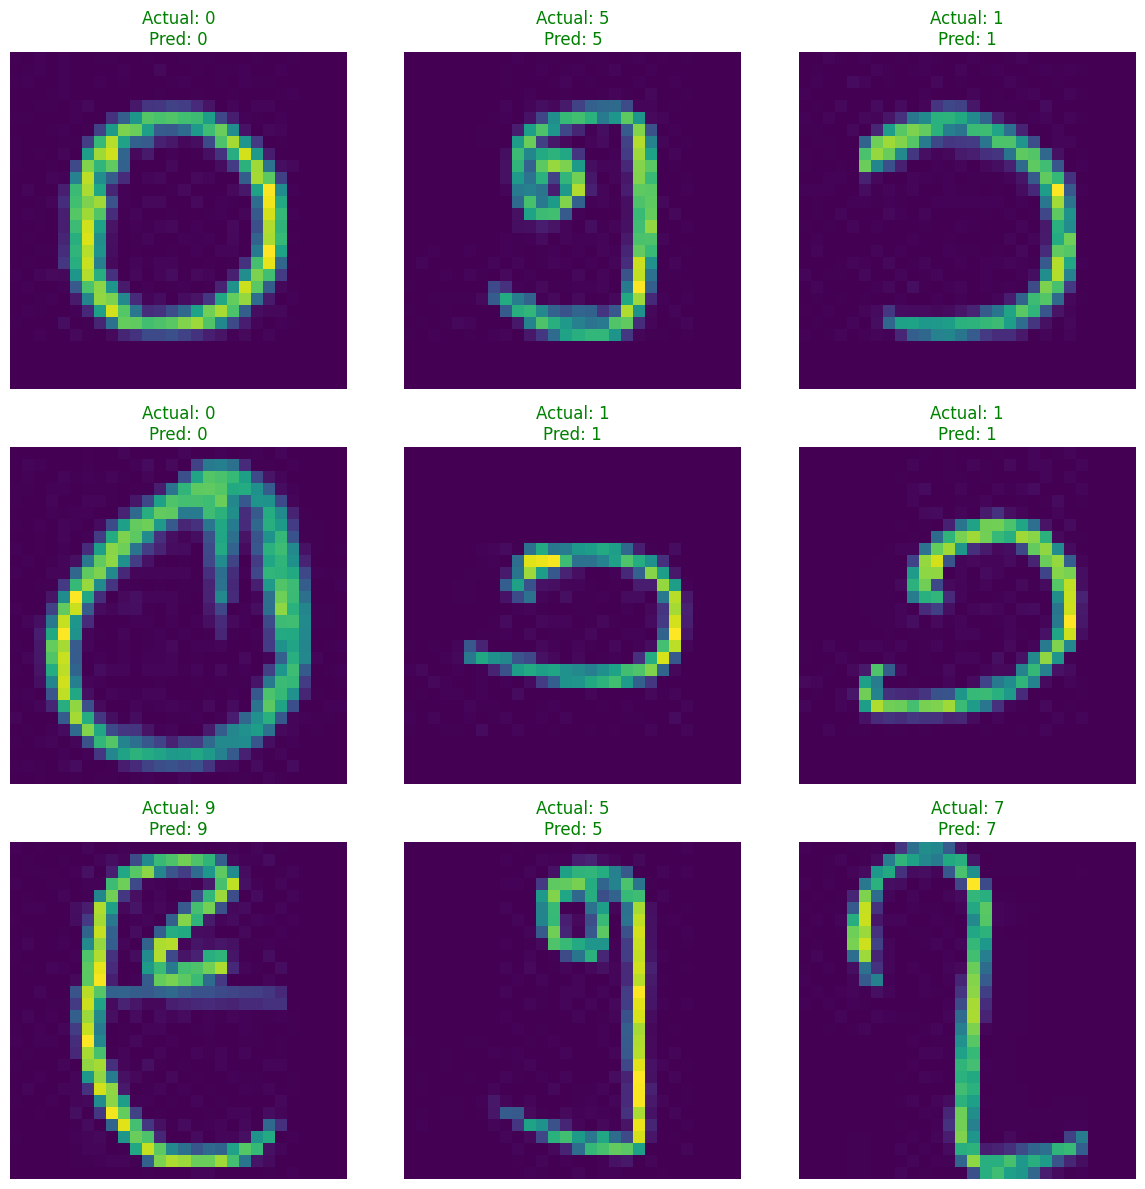

In [13]:
plt.figure(figsize=(12, 12))
model.eval()

start_idx = 111

for i in range(9):
    idx = start_idx + i

    example_test_image = np.array(testX[idx]).reshape(28, 28)
    actual_label = testDataset[idx]["label"]
    input_tensor = torch.tensor(testX[idx]).float().view(1, 1, 28, 28).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)
        predicted_label = predicted.item()

    plt.subplot(3, 3, i + 1)
    plt.imshow(example_test_image, cmap='viridis')

    color = 'green' if predicted_label == actual_label else 'red'
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}", fontsize=12, color=color)

    plt.axis('off')

plt.tight_layout()
plt.show()

## Understanding CNN

###  Intermediate Feature Maps များကို Visualizing ပြုလုပ်ခြင်း

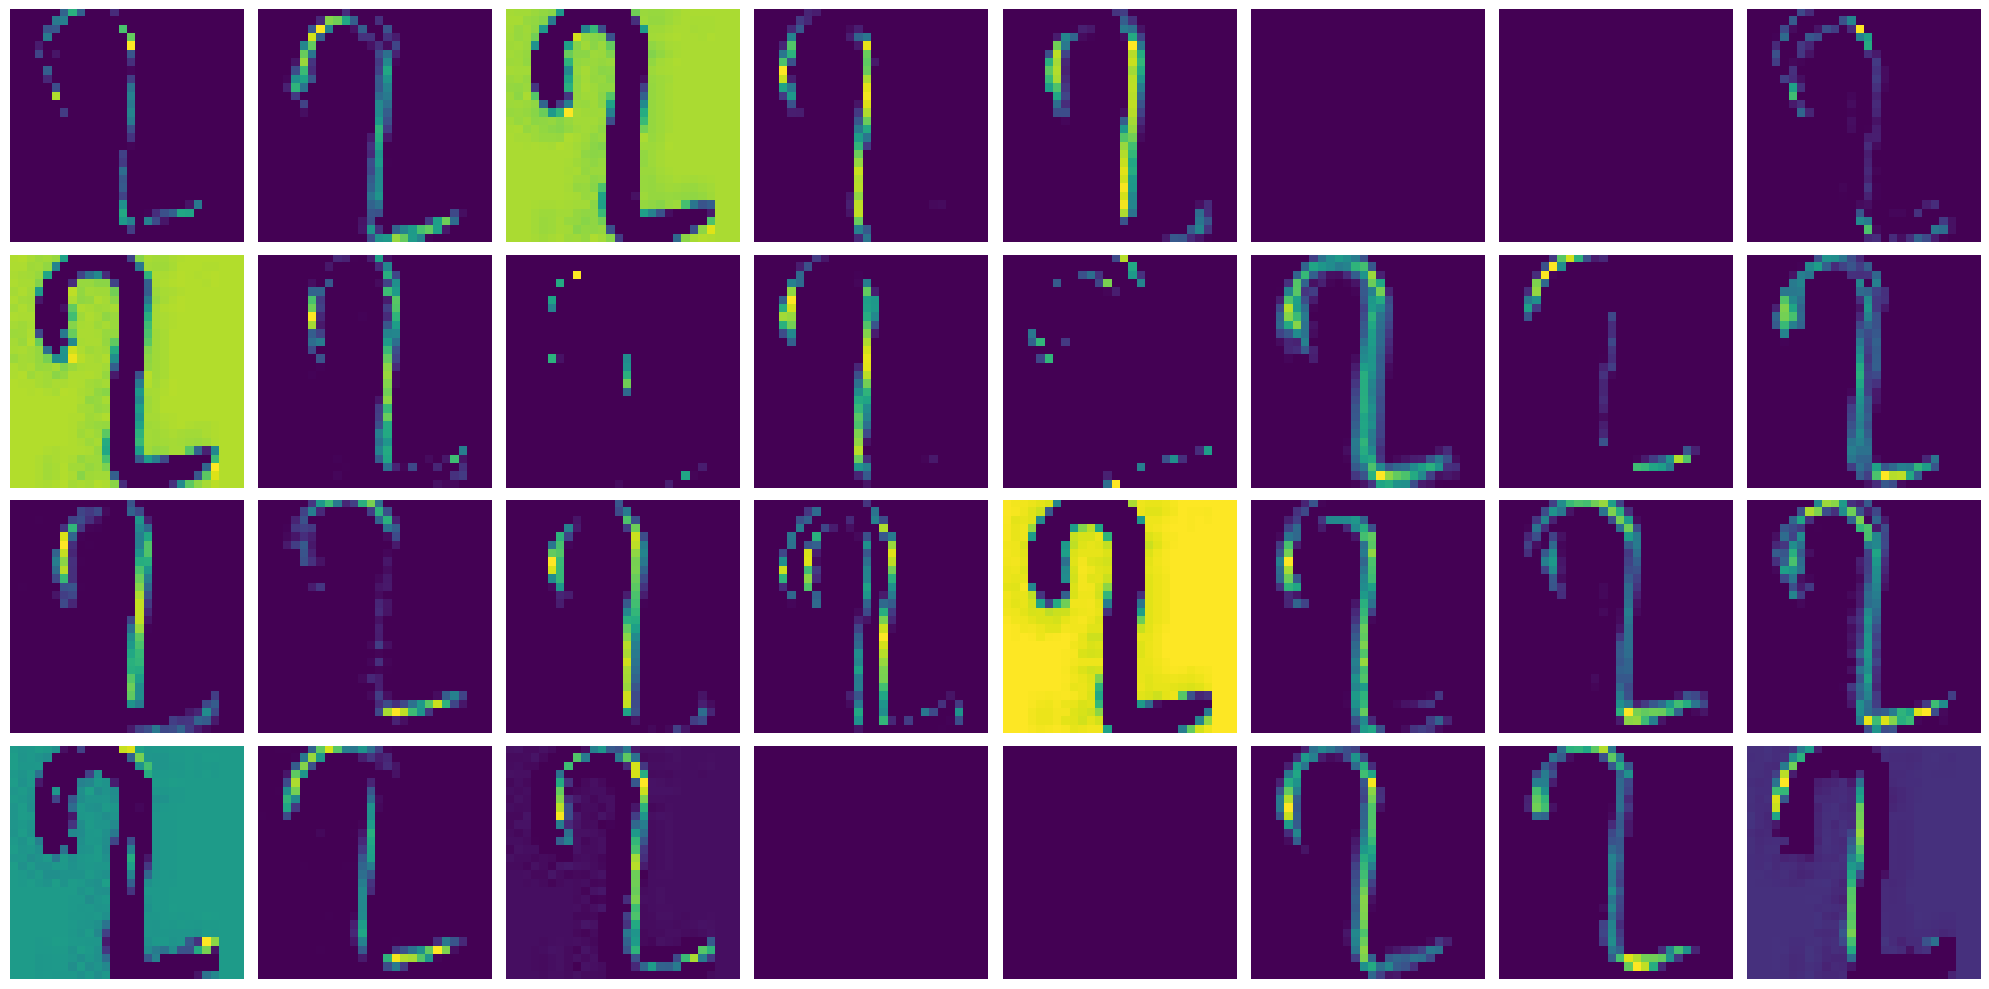

In [14]:
model.eval()
with torch.no_grad():
    feature_maps_conv1 = F.relu(model.conv1(input_tensor))

plt.figure(figsize=(20, 10))
for i in range(32): 
    plt.subplot(4, 8, i + 1)
    plt.imshow(feature_maps_conv1[0][i].cpu(), cmap='viridis')
    plt.axis('off')

plt.tight_layout()
plt.show()

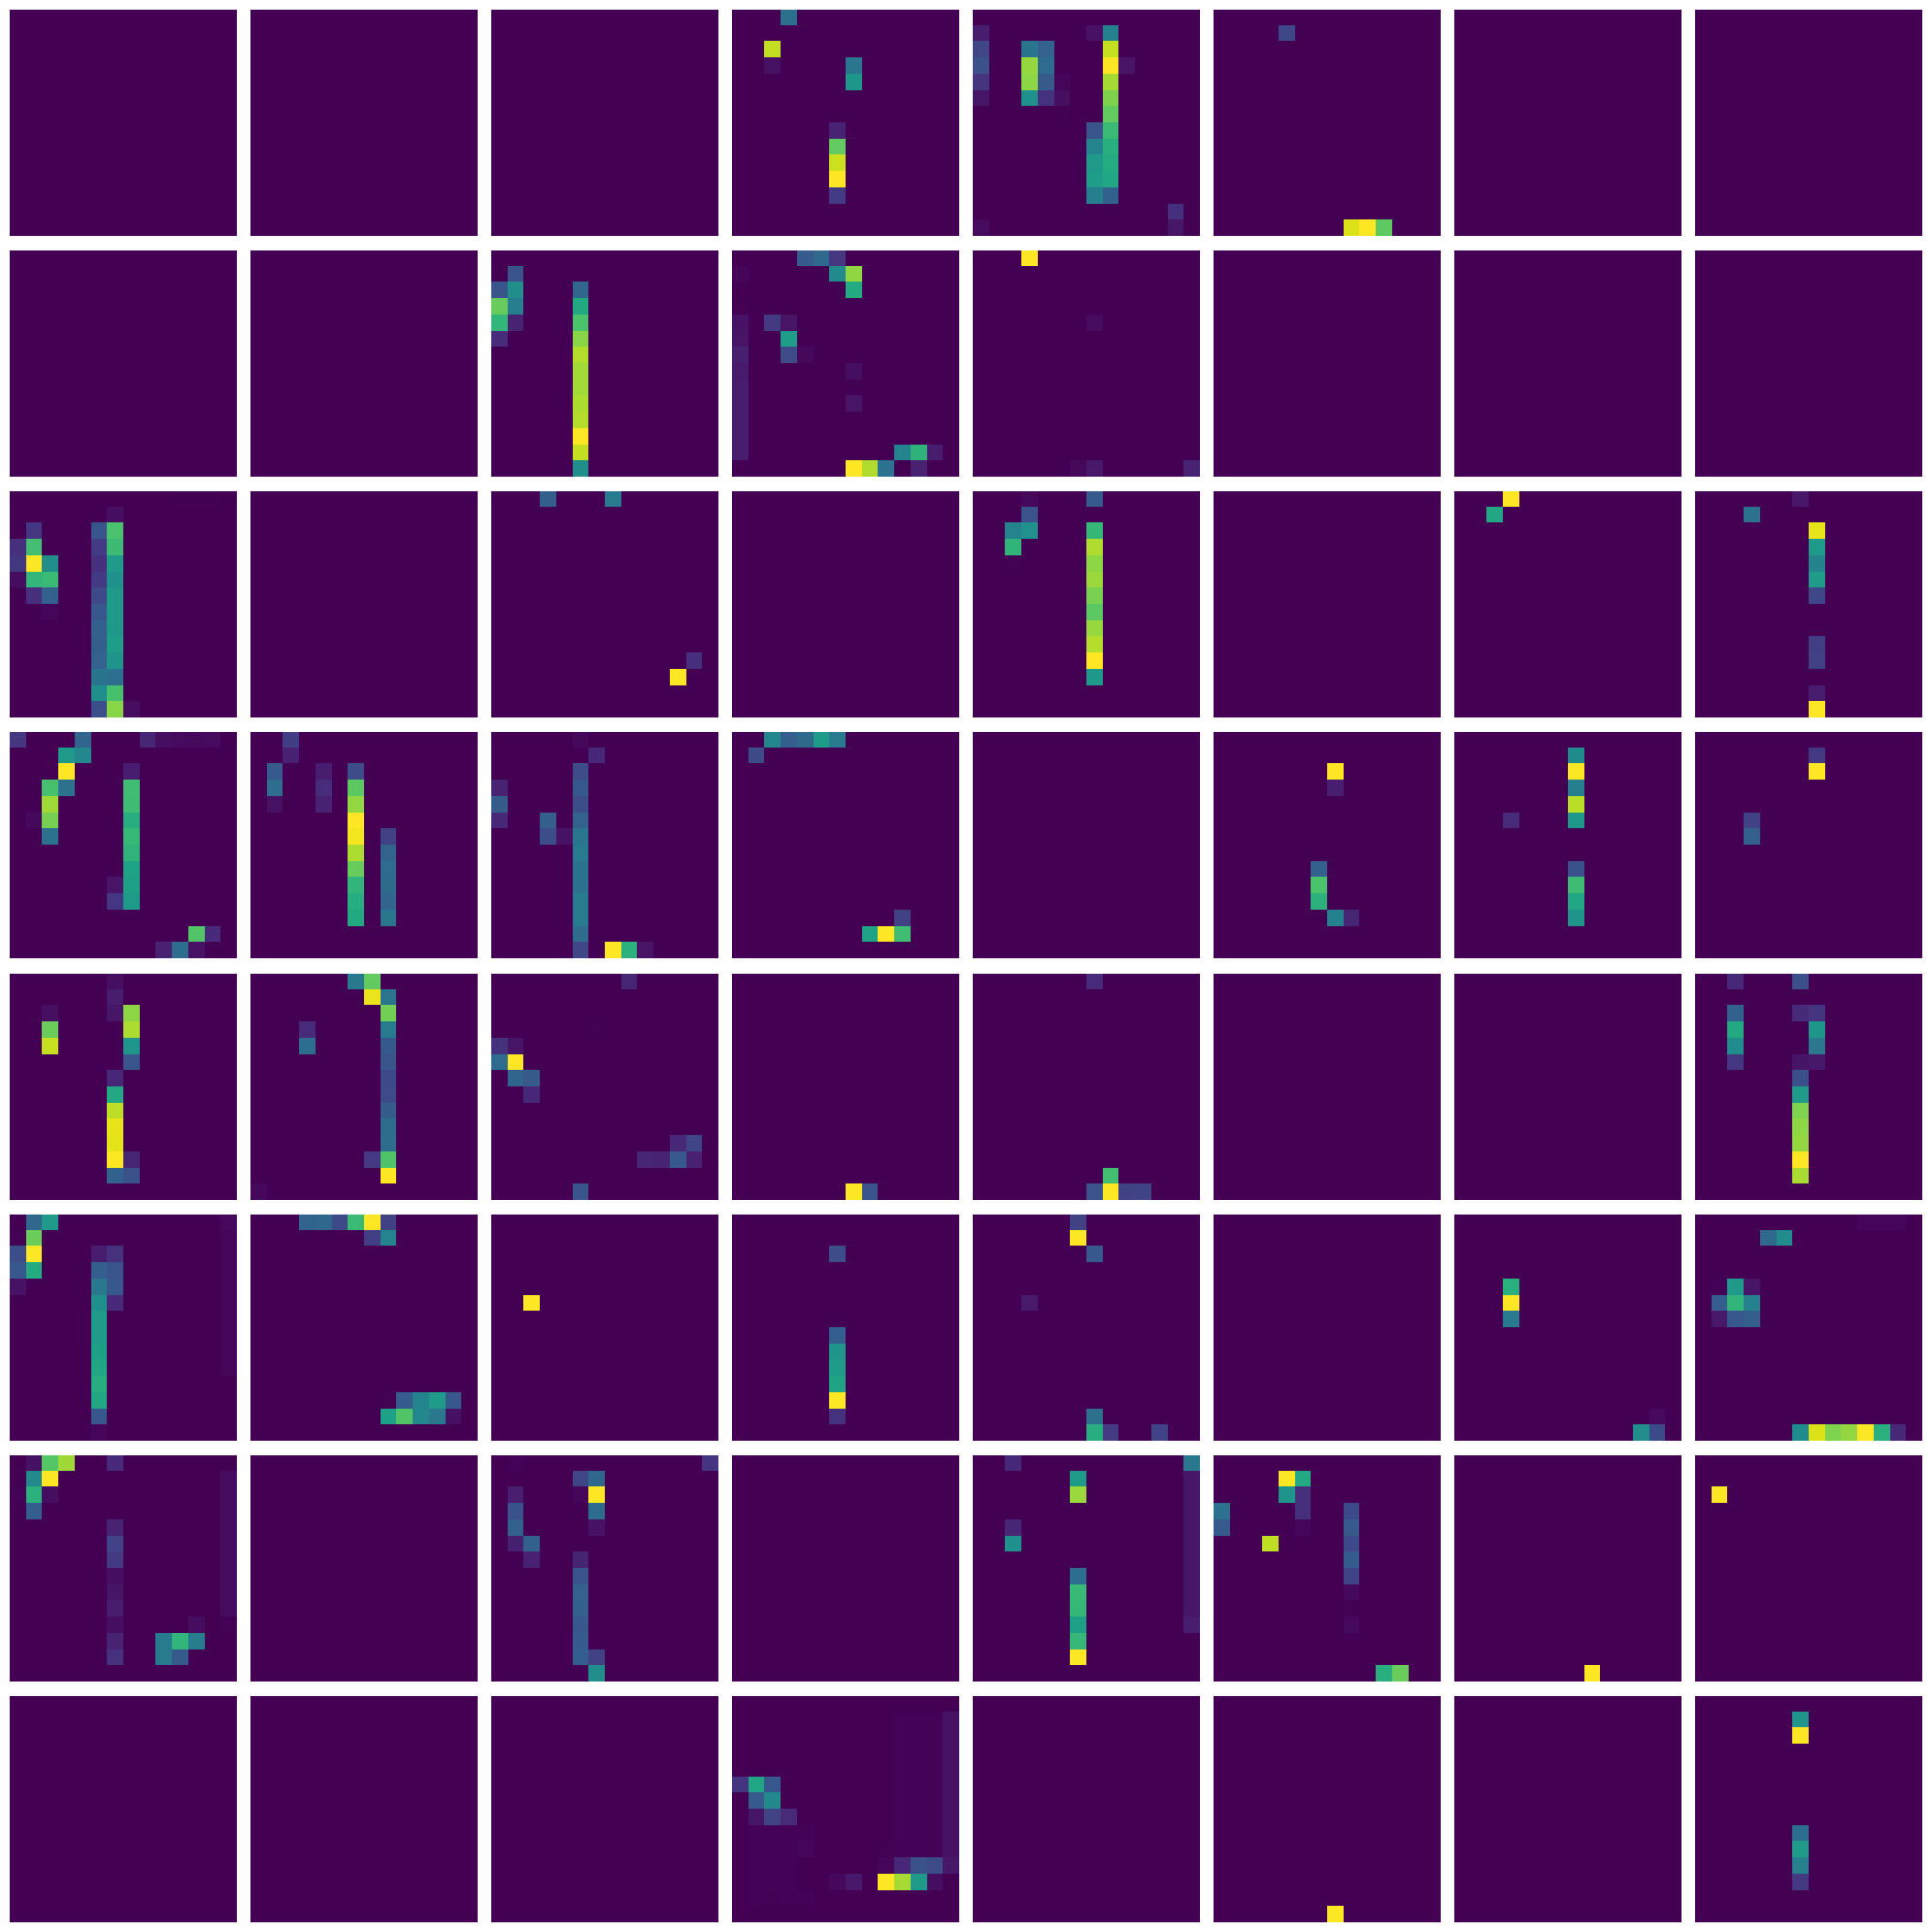

In [15]:
model.eval()
with torch.no_grad():
    x = F.relu(F.max_pool2d(model.conv1(input_tensor), 2))
    feature_maps_conv2 = F.relu(model.conv2(x))

plt.figure(figsize=(20, 20))
for i in range(64):
    plt.subplot(8, 8, i + 1)
    plt.imshow(feature_maps_conv2[0][i].cpu(), cmap='viridis')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Model မှားယွင်းစွာ ခန့်မှန်းလိုက်သော ပုံများကို စစ်ဆေးခြင်း (Visualizing Failures)

စုစုပေါင်း အမှားအရေအတွက်: 79 ခု


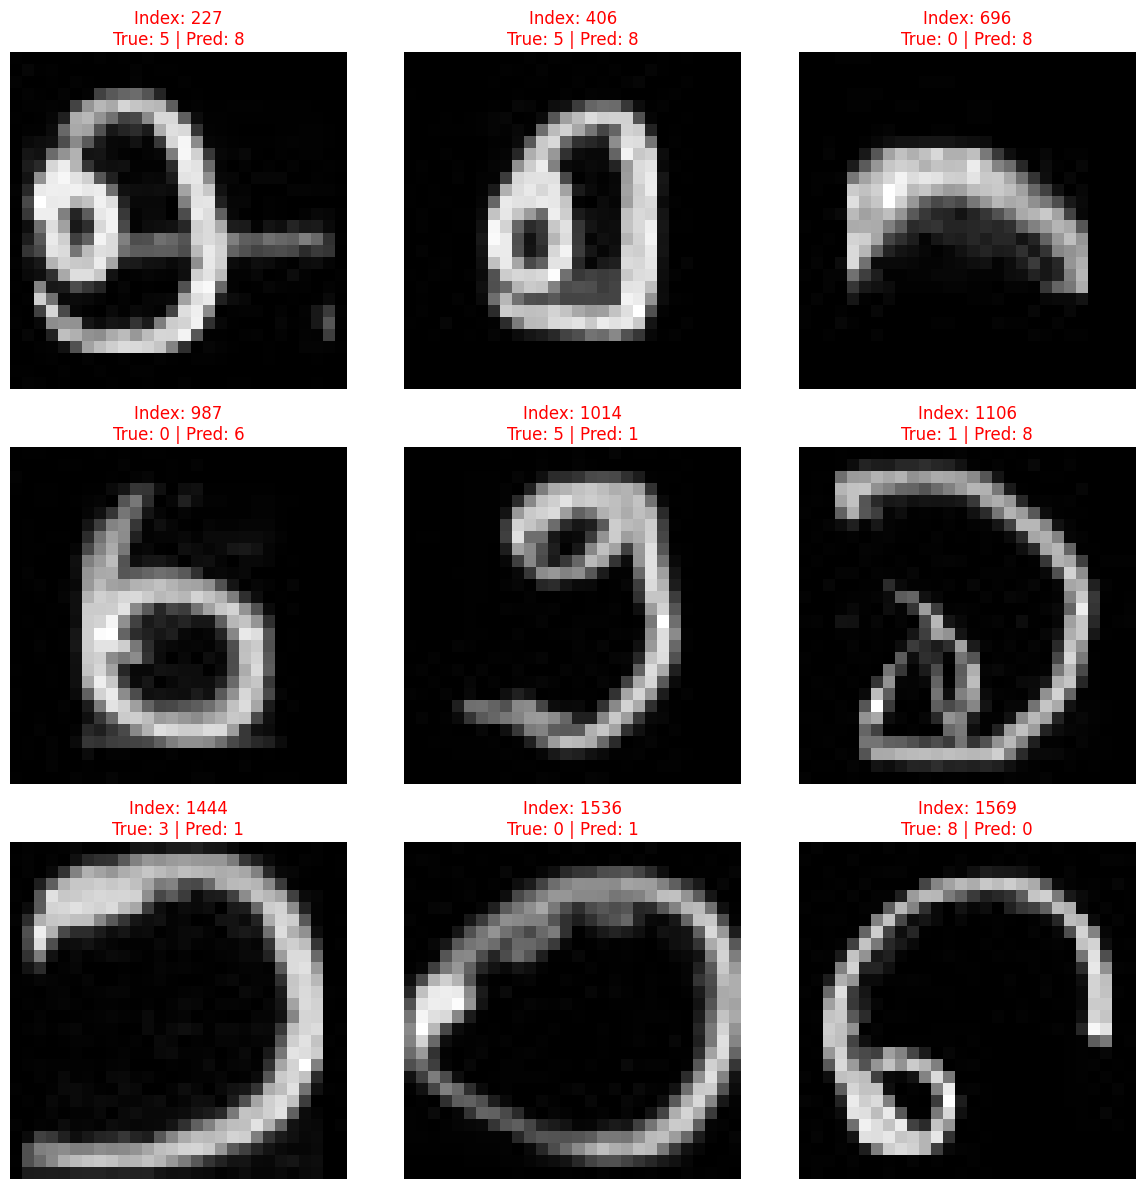

In [16]:
# မှားယွင်းသော ခန့်မှန်းချက်များ၏ Index များကို ရှာဖွေခြင်း
misclassified_indices = np.where(y_pred != y_true)[0]

print(f"စုစုပေါင်း အမှားအရေအတွက်: {len(misclassified_indices)} ခု")

plt.figure(figsize=(12, 12))
num_images = min(9, len(misclassified_indices))

for i in range(num_images):
    idx = misclassified_indices[i]
    img = np.array(testX[idx]).reshape(28, 28)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Index: {idx}\nTrue: {y_true[idx]} | Pred: {y_pred[idx]}", fontsize=12, color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Grad-CAM Heatmaps များအား ကြည့်ရှုခြင်း

Grad-CAM (Gradient-weighted Class Activation Mapping) သည် CNN model တစ်ခုက ဆုံးဖြတ်ချက်ချရာတွင် ပုံရိပ်၏ \
မည်သည့်အစိတ်အပိုင်းကို အဓိကကြည့်ရှုသွားသလဲဆိုသည်ကို ဖော်ပြပေးသော Visual Explanation နည်းပညာတစ်ခုဖြစ်သည်။

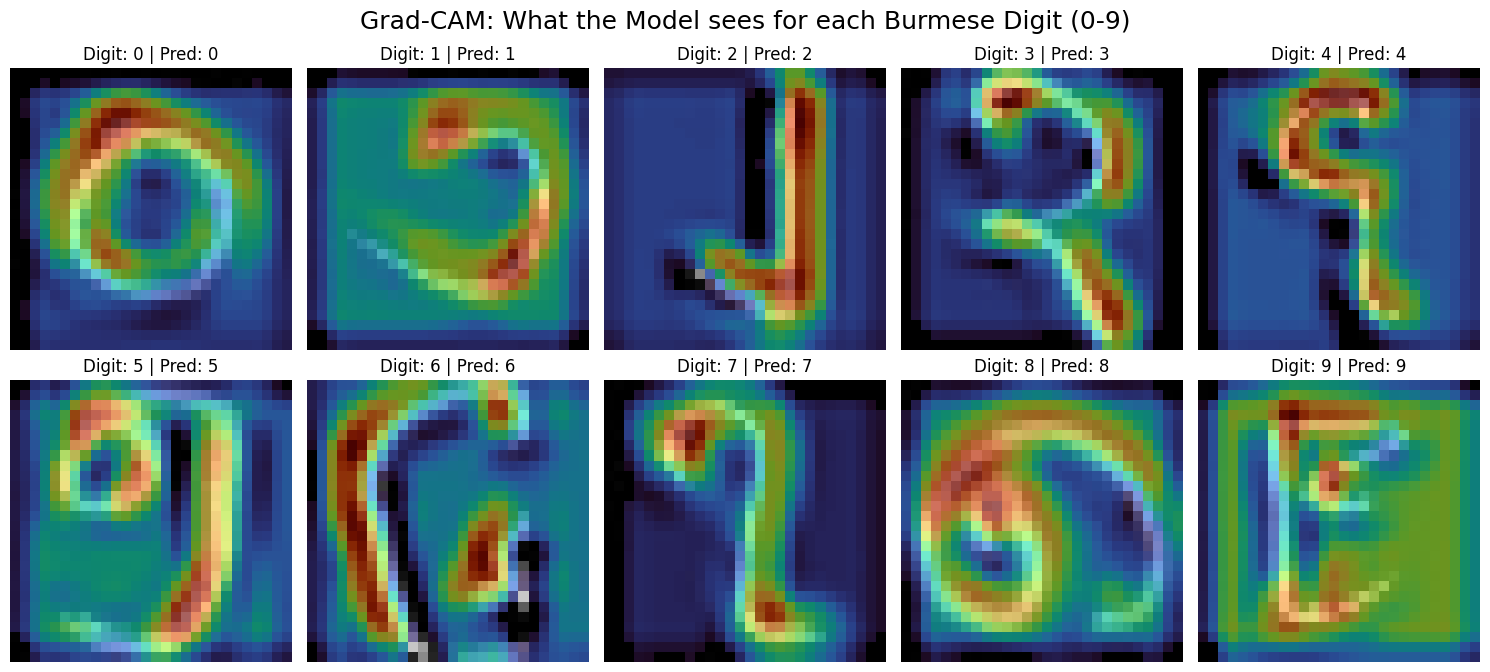

In [26]:
# ၁။ ၀ မှ ၉ အထိ တစ်ခုချင်းစီအတွက် ပထမဆုံးတွေ့သော index များကို ရှာခြင်း
y_true = np.array([td["label"] for td in testDataset])

sample_indices = []
for i in range(10):
    idx = np.where(y_true == i)[0][0]
    sample_indices.append(idx)

# ၂။ Grad-CAM အတွက် Hook function များ ပြင်ဆင်ခြင်း
gradients = None
activations = None

def save_gradient(grad):
    global gradients
    gradients = grad

def forward_hook(module, input, output):
    global activations
    activations = output
    output.register_hook(save_gradient)
    return output

# model.conv2 သည် နောက်ဆုံး conv layer ဖြစ်သည်
handle = model.conv2.register_forward_hook(forward_hook)

# ၃။ ၀ မှ ၉ အထိ တစ်ပုံချင်းစီအတွက် Heatmap ထုတ်ခြင်း
plt.figure(figsize=(15, 7))

for i, idx in enumerate(sample_indices):
    img_raw = testDataset[idx]["image"]
    input_tensor = torch.tensor(testX[idx]).float().view(1, 1, 28, 28).to(device)

    # Forward Pass
    model.eval()
    model.zero_grad()
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

    # Backward Pass (Target Class အတွက်)
    output[0, pred].backward()

    # Grad-CAM တွက်ချက်ခြင်း
    weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * activations, dim=1).squeeze()
    cam = torch.abs(cam)

    # Normalize နှင့် Resize
    cam = cam.detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam_resized = np.array(Image.fromarray(cam).resize((28, 28)))

    mask = cam_resized > 0.1
    masked_cam = np.where(mask, cam_resized, np.nan)

    # Plot
    plt.subplot(2, 5, i + 1)
    plt.imshow(img_raw, cmap='gray')
    plt.imshow(masked_cam, cmap='turbo', alpha=0.6)
    plt.title(f"Digit: {i} | Pred: {pred.item()}")
    plt.axis('off')

    # print(f"Digit {i} - CAM min: {cam.min():.4f}, max: {cam.max():.4f}, mean: {cam.mean():.4f}")

plt.suptitle("Grad-CAM: What the Model sees for each Burmese Digit (0-9)", fontsize=18)
plt.tight_layout()
plt.show()
handle.remove()

`အနီရောင် (Hot):` Model ၏ ဆုံးဖြတ်ချက်အတွက် အရေးကြီးဆုံး အစိတ်အပိုင်းများ

`ဝါ/စိမ်း (Warm): `Model က ဒုတိယဦးစားပေးအဖြစ် ထည့်သွင်းစဉ်းစားသော နေရာများ။

`ပြာ/မှိန် (Cold):` Model ၏ ခန့်မှန်းချက်အပေါ် သက်ရောက်မှုမရှိသော နောက်ခံအစိတ်အပိုင်းများ။